In [11]:
import torch, time, os, glob, datetime
import numpy as np
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import MultiStepLR
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128 | CUDA: True
GPU: Tesla T4


In [12]:
import importlib, subprocess, sys
for pkg in ["skimage", "cv2"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable,"-m","pip","install","-q",
                        "scikit-image" if pkg=="skimage" else "opencv-python-headless"])
from skimage.metrics import peak_signal_noise_ratio as psnr
import cv2
print("deps ready")

deps ready


In [ ]:
SIGMA       = 25
PATCH_SIZE  = 40
STRIDE      = 10
SCALES      = [1, 0.9, 0.8, 0.7]
AUG_TIMES   = 1
BATCH_SIZE  = 128
LR          = 1e-3
MILESTONES  = [30, 60, 90]
GAMMA       = 0.2
EPOCHS      = 20          # first trained up to 20 epochs, then fine-tuned for 10 more epochs (30 epochs total)
DEPTH       = 17         # DnCNN-S
SAVE_DIR    = "models_dncnn_s_sigma25"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"sigma={SIGMA}, epochs={EPOCHS}, depth={DEPTH}")

sigma=25, epochs=20, depth=17


In [14]:
import os, glob, urllib.request

DATA_DIR = "data/Train400"
os.makedirs(DATA_DIR, exist_ok=True)

# Verified source: the authors' Train400 lives here, named test_001.png ... test_400.png
BASE = ("https://raw.githubusercontent.com/cszn/DnCNN/master/"
        "TrainingCodes/DnCNN_TrainingCodes_v1.0/data/Train400")

existing = glob.glob(DATA_DIR + "/*.png")
if len(existing) < 400:
    print(f"Downloading Train400 ({len(existing)} present)...")
    ok = 0; fail = 0
    for n in range(1, 401):
        fn = f"test_{n:03d}.png"
        dst = os.path.join(DATA_DIR, fn)
        if os.path.exists(dst):
            ok += 1; continue
        try:
            urllib.request.urlretrieve(f"{BASE}/{fn}", dst)
            ok += 1
        except Exception as e:
            fail += 1
            if fail <= 3: print("  fail", fn, e)
        if n % 100 == 0:
            print(f"  {n}/400 ...")
    print(f"done: {ok} ok, {fail} failed")

files = sorted(glob.glob(DATA_DIR + "/*.png"))
print(f"Train400 images available: {len(files)}")
assert len(files) > 0, ("No training images. Manually upload the Train400 PNGs to "
                        + DATA_DIR + " if the download was blocked.")

Train400 images available: 400


In [15]:
import urllib.request, os, types

RAW = "https://raw.githubusercontent.com/cszn/DnCNN/master/TrainingCodes/dncnn_pytorch"
for fn in ["data_generator.py", "main_train.py"]:
    if not os.path.exists(fn):
        urllib.request.urlretrieve(f"{RAW}/{fn}", fn)
        print("downloaded", fn)

# Their data_generator imports cleanly (no top-level side effects beyond __main__ guard)
import data_generator as dg
from data_generator import DenoisingDataset, data_aug, gen_patches, datagenerator
print("Imported authors' data pipeline:",
      [n for n in ["data_aug","gen_patches","datagenerator","DenoisingDataset"]])

# Show the author header so it's visible this is their code
with open("data_generator.py") as f:
    head = "".join([next(f) for _ in range(16)])
print("\n--- data_generator.py header (authors') ---\n" + head)

Imported authors' data pipeline: ['data_aug', 'gen_patches', 'datagenerator', 'DenoisingDataset']

--- data_generator.py header (authors') ---
# -*- coding: utf-8 -*-

# =============================================================================
#  @article{zhang2017beyond,
#    title={Beyond a {Gaussian} denoiser: Residual learning of deep {CNN} for image denoising},
#    author={Zhang, Kai and Zuo, Wangmeng and Chen, Yunjin and Meng, Deyu and Zhang, Lei},
#    journal={IEEE Transactions on Image Processing},
#    year={2017},
#    volume={26}, 
#    number={7}, 
#    pages={3142-3155}, 
#  }
# by Kai Zhang (08/2018)
# cskaizhang@gmail.com
# https://github.com/cszn
# modified on the code from https://github.com/SaoYan/DnCNN-PyTorch



In [16]:
# main_train.py runs argparse at import time, which breaks in a notebook.
# We extract only the authors' class definitions (DnCNN, sum_squared_error),
# which sit before the argparse block and the __main__ training run.
import types, torch

def import_authors_classes(path="main_train.py"):
    lines = open(path).read().splitlines()
    def idx(pred, start=0):
        for i in range(start, len(lines)):
            if pred(lines[i]): return i
        return -1
    i_argparse   = idx(lambda l: l.strip().startswith("parser = argparse"))
    i_firstclass = idx(lambda l: l.startswith("class "))
    i_main       = idx(lambda l: l.strip().startswith("if __name__"))
    # keep imports (before argparse) + the class block (firstclass .. __main__)
    head = lines[:i_argparse] + [""] + lines[i_firstclass : (i_main if i_main!=-1 else len(lines))]
    mod = types.ModuleType("authors_dncnn")
    exec(compile("\n".join(head), "authors_dncnn", "exec"), mod.__dict__)
    return mod

authors = import_authors_classes()
DnCNN = authors.DnCNN
sum_squared_error = authors.sum_squared_error
print("Imported authors' classes:", DnCNN.__name__, "+", sum_squared_error.__name__)

model = DnCNN().to(device)          # their defaults: depth=17, BN on, orthogonal init
criterion = sum_squared_error()
print("params:", sum(p.numel() for p in model.parameters()))

Imported authors' classes: DnCNN + sum_squared_error
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
init weight
params: 556096


In [17]:
from torch.optim.lr_scheduler import MultiStepLR
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = MultiStepLR(optimizer, milestones=MILESTONES, gamma=GAMMA)
print(f"Adam lr={LR}, MultiStepLR milestones={MILESTONES} gamma={GAMMA}")

Adam lr=0.001, MultiStepLR milestones=[30, 60, 90] gamma=0.2


In [18]:
import urllib.request
os.makedirs("Set12", exist_ok=True)
base = "https://raw.githubusercontent.com/cszn/DnCNN/master/testsets/Set12"
val_imgs = []
for n in range(1,13):
    p = f"Set12/{n:02d}.png"
    if not os.path.exists(p):
        try: urllib.request.urlretrieve(f"{base}/{n:02d}.png", p)
        except Exception as e: print("dl fail", n, e)
    if os.path.exists(p):
        im = cv2.imread(p, 0).astype("float32")/255.0
        val_imgs.append(im)
print("val images:", len(val_imgs))

@torch.no_grad()
def validate(net, sigma=SIGMA, seed=0):
    net.eval(); ps=[]
    for k,clean in enumerate(val_imgs):
        rng = np.random.default_rng(seed+k)
        noisy = clean + rng.normal(0, sigma/255.0, clean.shape)
        t = torch.from_numpy(noisy).float().unsqueeze(0).unsqueeze(0).to(device)
        den = net(t).squeeze().cpu().numpy().clip(0,1)
        ps.append(psnr(clean, den, data_range=1.0))
    net.train(); return float(np.mean(ps))

print(f"PSNR before training (random init): {validate(model):.2f} dB")

val images: 12
PSNR before training (random init): 20.35 dB


## Training loop

In [19]:
import numpy as np
# Build clean patches using the AUTHORS' datagenerator, then their DenoisingDataset.
xs = dg.datagenerator(data_dir=DATA_DIR)          # uint8, (N, 40, 40, 1)
xs = xs.astype("float32") / 255.0
xs = torch.from_numpy(xs.transpose((0, 3, 1, 2)))  # N,C,H,W  (their convention)
train_ds = DenoisingDataset(xs, SIGMA)             # their dataset: adds AWGN on the fly
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, drop_last=True)
print("patches:", tuple(xs.shape), "| batches/epoch:", len(train_dl))

history = []
for epoch in range(EPOCHS):
    scheduler.step(epoch)
    model.train()
    t0 = time.time(); running = 0.0; nb_ = 0
    for batch_y, batch_x in train_dl:
        batch_y, batch_x = batch_y.to(device), batch_x.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_y), batch_x)   # authors' loss; model returns y-out
        loss.backward(); optimizer.step()
        running += loss.item(); nb_ += 1
    val_psnr = validate(model)
    history.append({"epoch": epoch+1, "loss": running/nb_/BATCH_SIZE,
                    "val_psnr": val_psnr, "lr": optimizer.param_groups[0]["lr"]})
    print(f"epoch {epoch+1:3d}/{EPOCHS} | loss {running/nb_/BATCH_SIZE:8.4f} "
          f"| Set12 PSNR {val_psnr:.2f} dB | {time.time()-t0:.1f}s")
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"model_{epoch+1:03d}.pth"))
print("done. checkpoints in", SAVE_DIR)

^_^-training data finished-^_^
patches: (238336, 1, 40, 40) | batches/epoch: 1862


/tmp/ipykernel_6560/545881117.py:13: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step(epoch)
/tmp/ipykernel_6560/545881117.py:13: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(epoch)


epoch   1/20 | loss   2.8906 | Set12 PSNR 28.85 dB | 362.8s
epoch   2/20 | loss   1.5750 | Set12 PSNR 29.38 dB | 363.0s
epoch   3/20 | loss   1.4886 | Set12 PSNR 29.40 dB | 362.8s
epoch   4/20 | loss   1.4403 | Set12 PSNR 29.82 dB | 362.9s
epoch   5/20 | loss   1.4045 | Set12 PSNR 29.89 dB | 362.9s
epoch   6/20 | loss   1.3793 | Set12 PSNR 30.02 dB | 363.2s
epoch   7/20 | loss   1.3653 | Set12 PSNR 29.90 dB | 363.3s
epoch   8/20 | loss   1.3450 | Set12 PSNR 30.11 dB | 363.3s
epoch   9/20 | loss   1.3356 | Set12 PSNR 30.15 dB | 363.4s
epoch  10/20 | loss   1.3327 | Set12 PSNR 30.18 dB | 363.3s
epoch  11/20 | loss   1.3610 | Set12 PSNR 30.13 dB | 363.4s
epoch  12/20 | loss   1.3306 | Set12 PSNR 30.19 dB | 363.3s
epoch  13/20 | loss   1.3190 | Set12 PSNR 30.21 dB | 363.0s
epoch  14/20 | loss   1.3126 | Set12 PSNR 30.28 dB | 363.2s
epoch  15/20 | loss   1.3065 | Set12 PSNR 30.29 dB | 363.1s
epoch  16/20 | loss   1.3023 | Set12 PSNR 30.33 dB | 363.0s
epoch  17/20 | loss   1.2995 | Set12 PSN

## 9. Progress curves

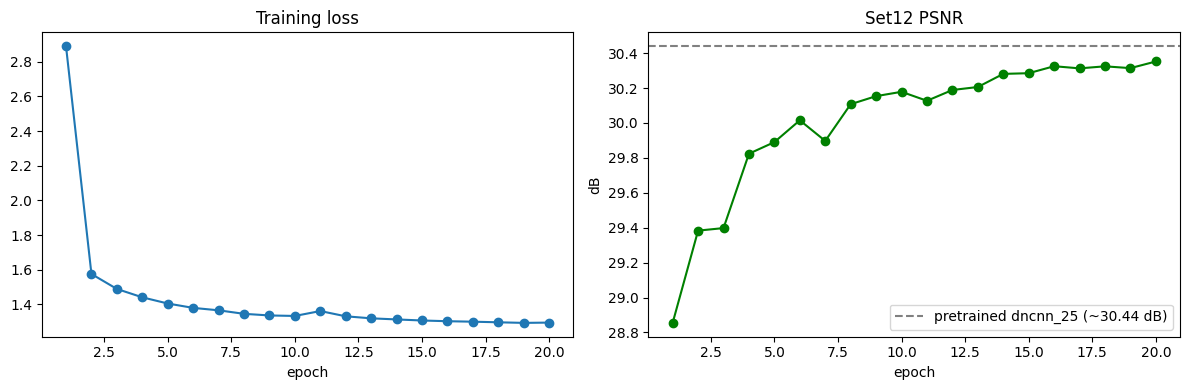

In [20]:
import matplotlib.pyplot as plt
ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(ep, [h["loss"] for h in history], marker="o"); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(ep, [h["val_psnr"] for h in history], marker="o", color="green")
ax[1].axhline(30.44, ls="--", c="gray", label="pretrained dncnn_25 (~30.44 dB)")
ax[1].set_title("Set12 PSNR"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("dB"); ax[1].legend()
plt.tight_layout(); plt.show()

In [21]:
EPOCHS = 100   # update so the progress print reads correctly

for epoch in range(20, EPOCHS):      # continue AFTER epoch 20 (prints as 21..100)
    scheduler.step(epoch)            # keep the same form your run used
    model.train()
    t0 = time.time(); running = 0.0; nb_ = 0
    for batch_y, batch_x in train_dl:
        batch_y, batch_x = batch_y.to(device), batch_x.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_y), batch_x)
        loss.backward(); optimizer.step()
        running += loss.item(); nb_ += 1
    val_psnr = validate(model)
    history.append({"epoch": epoch+1, "loss": running/nb_/BATCH_SIZE,
                    "val_psnr": val_psnr, "lr": optimizer.param_groups[0]["lr"]})
    print(f"epoch {epoch+1:3d}/{EPOCHS} | loss {running/nb_/BATCH_SIZE:8.4f} "
          f"| Set12 PSNR {val_psnr:.2f} dB | {time.time()-t0:.1f}s")
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"model_{epoch+1:03d}.pth"))
print("done. checkpoints in", SAVE_DIR)

/tmp/ipykernel_6560/774162776.py:4: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(epoch)            # keep the same form your run used


epoch  21/100 | loss   1.2901 | Set12 PSNR 30.36 dB | 362.5s
epoch  22/100 | loss   1.2888 | Set12 PSNR 30.34 dB | 363.3s
epoch  23/100 | loss   1.2864 | Set12 PSNR 30.35 dB | 363.1s
epoch  24/100 | loss   1.2846 | Set12 PSNR 30.36 dB | 363.1s
epoch  25/100 | loss   1.3051 | Set12 PSNR 30.33 dB | 363.3s
epoch  26/100 | loss   1.2890 | Set12 PSNR 30.34 dB | 363.1s
epoch  27/100 | loss   1.2846 | Set12 PSNR 30.37 dB | 363.1s
epoch  28/100 | loss   1.2840 | Set12 PSNR 30.38 dB | 363.1s
epoch  29/100 | loss   1.2816 | Set12 PSNR 30.39 dB | 363.0s
epoch  30/100 | loss   1.2800 | Set12 PSNR 30.41 dB | 363.2s


KeyboardInterrupt: 

Training stopped at epoch 30

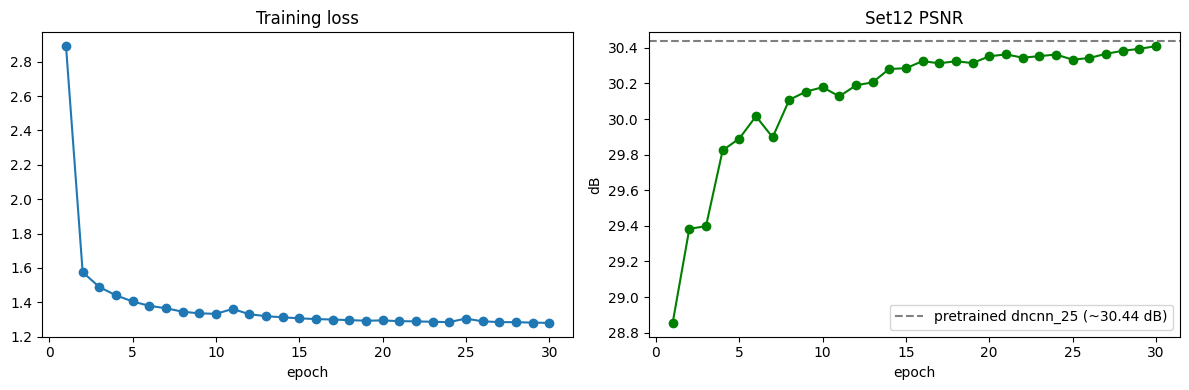

In [22]:

ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(ep, [h["loss"] for h in history], marker="o"); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(ep, [h["val_psnr"] for h in history], marker="o", color="green")
ax[1].axhline(30.44, ls="--", c="gray", label="pretrained dncnn_25 (~30.44 dB)")
ax[1].set_title("Set12 PSNR"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("dB"); ax[1].legend()
plt.tight_layout(); plt.show()